In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("newslab/cholecseg8k")

print("Path to dataset files:", path)

100%|██████████| 2.89G/2.89G [00:25<00:00, 121MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/newslab/cholecseg8k/versions/11


In [ ]:
import os

# Let's see the first 10 files to understand the naming
for root, dirs, files in os.walk(path):
    if files:
        print(f"Folder: {root}")
        print(f"Sample files: {files[:5]}")
        break # Just show the first folder found

Folder: /root/.cache/kagglehub/datasets/newslab/cholecseg8k/versions/11/video55/video55_00588
Sample files: ['frame_614_endo_watershed_mask.png', 'frame_614_endo.png', 'frame_591_endo_watershed_mask.png', 'frame_603_endo_watershed_mask.png', 'frame_662_endo_mask.png']


In [ ]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models.detection import maskrcnn_resnet50_fpn

In [ ]:
all_images = []
all_masks = []

# This looks for ANY file with 'endo' in the name and tries to find a matching 'mask'
for root, dirs, files in os.walk(path):
    for file in files:
        if "endo.png" in file.lower():
            img_path = os.path.join(root, file)
            # Try common mask naming patterns
            mask_path = img_path.replace("endo.png", "mask.png")

            if os.path.exists(mask_path):
                all_images.append(img_path)
                all_masks.append(mask_path)

print(f"Successfully found {len(all_images)} image-mask pairs.")

if len(all_images) == 0:
    print("STILL 0? Let's try a broader search...")
    # Broad search: find all PNGs and see if they have a 'mask' version
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".png") and "mask" not in file:
                img_path = os.path.join(root, file)
                # This assumes the mask has 'mask' in the name
                potential_mask = img_path.replace(".png", "_mask.png")
                if os.path.exists(potential_mask):
                    all_images.append(img_path)
                    all_masks.append(potential_mask)
    print(f"Broad search found {len(all_images)} pairs.")

Successfully found 0 image-mask pairs.
STILL 0? Let's try a broader search...
Broad search found 8080 pairs.


In [ ]:
class CholecDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        # self.transforms = T.Compose([T.ToTensor()])
        # Replace the old self.transforms in Cell 2 with this:
        self.transforms = T.Compose([
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Handles lighting changes
    T.RandomHorizontalFlip(p=0.5), # Handles different surgical angles
    T.ToTensor(),])

    def __getitem__(self, idx):
        # 1. Load Image as RGB
        img = Image.open(self.image_paths[idx]).convert("RGB")

        # 2. Load Mask and CONVERT TO GRAYSCALE ('L') to fix the Shape Error
        mask = Image.open(self.mask_paths[idx]).convert("L")
        mask = np.array(mask)

        # 3. Identify unique objects (0 is background)
        obj_ids = np.unique(mask)
        obj_ids = obj_ids[obj_ids > 0] # Remove background

        # 4. Create binary masks for each object
        if len(obj_ids) > 0:
            masks = (mask == obj_ids[:, None, None]).astype(np.uint8)
        else:
            # Handle empty masks
            masks = np.zeros((0, mask.shape[0], mask.shape[1]), dtype=np.uint8)

        # 5. Calculate bounding boxes
        num_objs = len(obj_ids)
        boxes = []
        valid_objs = []

        for i in range(num_objs):
            pos = np.where(masks[i])
            if len(pos[0]) > 0: # Ensure the object actually exists in the mask
                xmin, xmax = np.min(pos[1]), np.max(pos[1])
                ymin, ymax = np.min(pos[0]), np.max(pos[0])
                if xmax > xmin and ymax > ymin:
                    boxes.append([xmin, ymin, xmax, ymax])
                    valid_objs.append(obj_ids[i])

        # 6. If no valid objects found, create a dummy box to prevent crash
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
            masks = torch.zeros((0, mask.shape[0], mask.shape[1]), dtype=torch.uint8)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(valid_objs, dtype=torch.int64)
            masks = torch.as_tensor(masks[:len(boxes)], dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks
        }

        return self.transforms(img), target

    def __len__(self):
        return len(self.image_paths)

# Let's restart the loader with the fix
dataset = CholecDataset(all_images[:500], all_masks[:500])
data_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
print("Dataset fixed and reloaded!")

Dataset fixed and reloaded!


In [ ]:
import torchvision.transforms.v2 as transforms # Modern transforms

In [ ]:
import torchvision
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights

# 1. Use 256 classes to be safe (handles any pixel value from 0-255)
num_classes = 256

# 2. Load the model
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=weights)

# 3. Adjust the head to handle 256 classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

# 4. Move to device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

print(f"Starting training on {device}...")
model.train()

for epoch in range(1):
    for i, (images, targets) in enumerate(data_loader):
        # SKIP images with no objects to prevent errors
        if any(len(t["boxes"]) == 0 for t in targets):
            continue

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        losses.backward()
        optimizer.step()

        if i % 5 == 0:
            print(f"Iteration {i}, Loss: {losses.item():.4f}")

print("Training complete!")

Starting training on cuda...
Iteration 0, Loss: 7.8716
Iteration 5, Loss: 3.9648
Iteration 10, Loss: 2.3960
Iteration 15, Loss: 2.7391
Iteration 20, Loss: 1.9684
Iteration 25, Loss: 1.9845
Iteration 30, Loss: 2.2227
Iteration 35, Loss: 2.1345
Iteration 40, Loss: 2.2172
Iteration 45, Loss: 1.7487
Iteration 50, Loss: 1.8330
Iteration 55, Loss: 1.7213
Iteration 60, Loss: 1.7747
Iteration 65, Loss: 1.7355
Iteration 70, Loss: 1.6298
Iteration 75, Loss: 1.5725
Iteration 80, Loss: 1.5032
Iteration 85, Loss: 1.5026
Iteration 90, Loss: 1.6253
Iteration 95, Loss: 1.4845
Iteration 100, Loss: 1.4039
Iteration 105, Loss: 1.6144
Iteration 110, Loss: 1.4014
Iteration 115, Loss: 1.6995
Iteration 120, Loss: 1.3235
Iteration 125, Loss: 1.4145
Iteration 130, Loss: 1.4446
Iteration 135, Loss: 1.7625
Iteration 140, Loss: 1.2827
Iteration 145, Loss: 1.4807
Iteration 150, Loss: 1.7139
Iteration 155, Loss: 1.4312
Iteration 160, Loss: 1.7199
Iteration 165, Loss: 1.2710
Iteration 170, Loss: 1.0741
Iteration 175

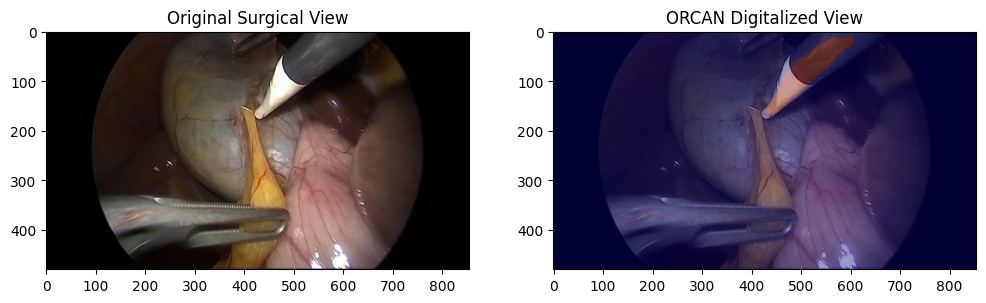

In [ ]:
model.eval()
img, _ = dataset[10] # Pick an image
with torch.no_grad():
    prediction = model([img.to(device)])

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Surgical View")
plt.imshow(img.permute(1, 2, 0))

plt.subplot(1, 2, 2)
plt.title("ORCAN Digitalized View")
plt.imshow(img.permute(1, 2, 0))
if len(prediction[0]['masks']) > 0:
    # Overlay the first detected mask (e.g., Gallbladder or Liver)
    mask = prediction[0]['masks'][0, 0].cpu().numpy()
    plt.imshow(mask > 0.5, alpha=0.4, cmap='jet')

plt.show()

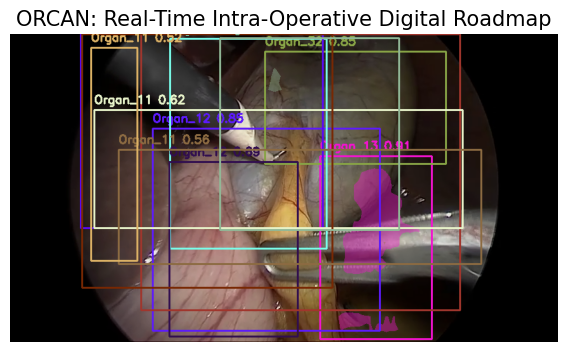

In [ ]:
import cv2 # Fixes the NameError
import numpy as np

def get_surgical_hud(img, prediction, threshold=0.5):
    # Convert tensor to a format OpenCV can draw on (BGR/RGB uint8)
    img_np = (img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8).copy()
    img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR) # OpenCV likes BGR

    # Class mapping for CholecSeg8k
    CLASS_NAMES = {1: "Liver", 2: "Gallbladder", 3: "Hepatoduodenal Ligament",
                   4: "Surgical Tool", 5: "Abdominal Wall"}

    for i in range(len(prediction[0]['masks'])):
        score = prediction[0]['scores'][i].item()
        if score > threshold:
            # 1. Get Mask
            mask = prediction[0]['masks'][i, 0].cpu().numpy()
            mask = (mask > 0.5)

            # 2. Generate Color
            color = [int(c) for c in np.random.randint(0, 255, (3,))]

            # 3. Draw Mask Overlay
            overlay = img_np.copy()
            overlay[mask] = color
            cv2.addWeighted(overlay, 0.4, img_np, 0.6, 0, img_np)

            # 4. Draw Box and Label
            box = prediction[0]['boxes'][i].cpu().numpy().astype(int)
            label_id = prediction[0]['labels'][i].item()
            label_name = CLASS_NAMES.get(label_id, f"Organ_{label_id}")

            cv2.rectangle(img_np, (box[0], box[1]), (box[2], box[3]), color, 2)
            cv2.putText(img_np, f"{label_name} {score:.2f}", (box[0], box[1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB) # Convert back for Matplotlib

# --- RUN AND SHOW ---
model.eval()
img, _ = dataset[25]
with torch.no_grad():
    prediction = model([img.to(device)])

hud_view = get_surgical_hud(img, prediction)
plt.figure(figsize=(8, 4))
plt.imshow(hud_view)
plt.axis('off')
plt.title("ORCAN: Real-Time Intra-Operative Digital Roadmap", fontsize=15)
plt.show()

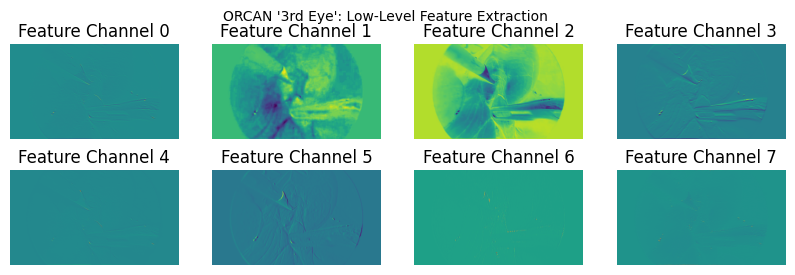

In [ ]:
def visualize_feature_maps(model, img):
    # We look at the first layer of the ResNet backbone
    feature_extractor = model.backbone.body.conv1

    with torch.no_grad():
        feature_maps = feature_extractor(img.unsqueeze(0).to(device))

    # Plot the first 8 filters
    fig, axes = plt.subplots(2, 4, figsize=(10, 3))
    for i, ax in enumerate(axes.flat):
        f_map = feature_maps[0, i].cpu().numpy()
        ax.imshow(f_map, cmap='viridis')
        ax.axis('off')
        ax.set_title(f"Feature Channel {i}")

    plt.suptitle("ORCAN '3rd Eye': Low-Level Feature Extraction", fontsize=10)
    plt.show()

visualize_feature_maps(model, img)